In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid", rc={"figure.figsize": (12, 8)})

# Load the processed dataset
data_path = "../data/processed_dblp.parquet"
analyticalData = pd.read_parquet(data_path)
print("Loaded rows:", len(analyticalData))
print("Columns:", analyticalData.columns.tolist())

Loaded rows: 50000
Columns: ['id', 'venue', 'year', 'n_citation', 'abstract', 'authors', 'references', 'algorithm', 'algorithms', 'analysis', 'application', 'applications', 'approach', 'based', 'control', 'data', 'design', 'different', 'framework', 'high', 'image', 'information', 'large', 'learning', 'level', 'method', 'methods', 'model', 'models', 'network', 'networks', 'new', 'number', 'order', 'paper', 'performance', 'present', 'problem', 'problems', 'process', 'propose', 'proposed', 'provide', 'real', 'research', 'results', 'set', 'software', 'study', 'systems', 'techniques', 'time', 'use', 'used', 'user', 'using', 'work']


In [11]:
if "title" in analyticalData.columns:
    analyticalData["text"] = analyticalData["title"].fillna("") + " " + analyticalData["abstract"].fillna("")
else:
    analyticalData["text"] = analyticalData["abstract"].fillna("")

analyticalData = analyticalData[analyticalData["text"].str.strip() != ""].copy()
print("Text rows after filtering empty text:", len(analyticalData))

Text rows after filtering empty text: 50000


In [12]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
text_matrix = vectorizer.fit_transform(analyticalData["text"])
print("TF-IDF shape:", text_matrix.shape)

TF-IDF shape: (50000, 10000)


In [13]:
n_components = 3
svd = TruncatedSVD(n_components=n_components, random_state=42) # dimensionality reduction using truncated SVD
reduced_matrix = svd.fit_transform(text_matrix)
print(f"Reduced matrix shape: {reduced_matrix.shape}")
print(f"Explained variance ratio sum: {svd.explained_variance_ratio_.sum():.4f}")

Reduced matrix shape: (50000, 3)
Explained variance ratio sum: 0.0102


In [14]:
candidate_clusters = [3, 4, 5, 6, 7, 8] # different numbers of clusters to try out
silhouette_scores = {}
for k in candidate_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_matrix)
    score = silhouette_score(reduced_matrix, labels)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Best k by silhouette score: {best_k}")

k=3: silhouette=0.2985
k=4: silhouette=0.2868
k=5: silhouette=0.2871
k=6: silhouette=0.2542
k=7: silhouette=0.2565
k=8: silhouette=0.2548
Best k by silhouette score: 3


In [15]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) # final kmeans model so we can use it for future predictions
analyticalData["cluster"] = final_kmeans.fit_predict(reduced_matrix)

plot_sample = analyticalData.sample(n=min(5000, len(analyticalData)), random_state=42) # using a sample for plotting if the dataset is large
plot_sample = plot_sample.reset_index(drop=True)

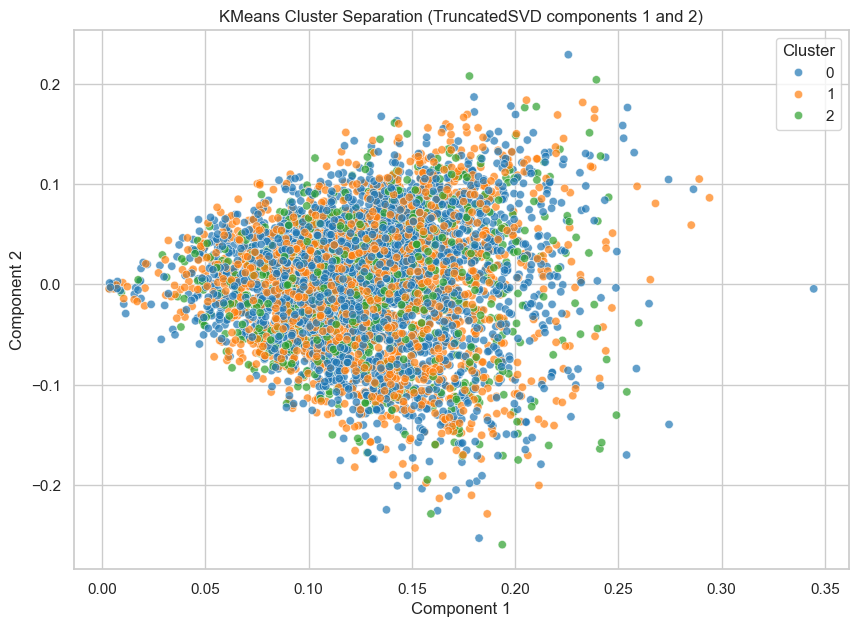

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=reduced_matrix[plot_sample.index, 0],
    y=reduced_matrix[plot_sample.index, 1],
    hue=plot_sample["cluster"],
    palette="tab10",
    legend="full",
    alpha=0.7
)
plt.title("KMeans Cluster Separation (TruncatedSVD components 1 and 2)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.show()

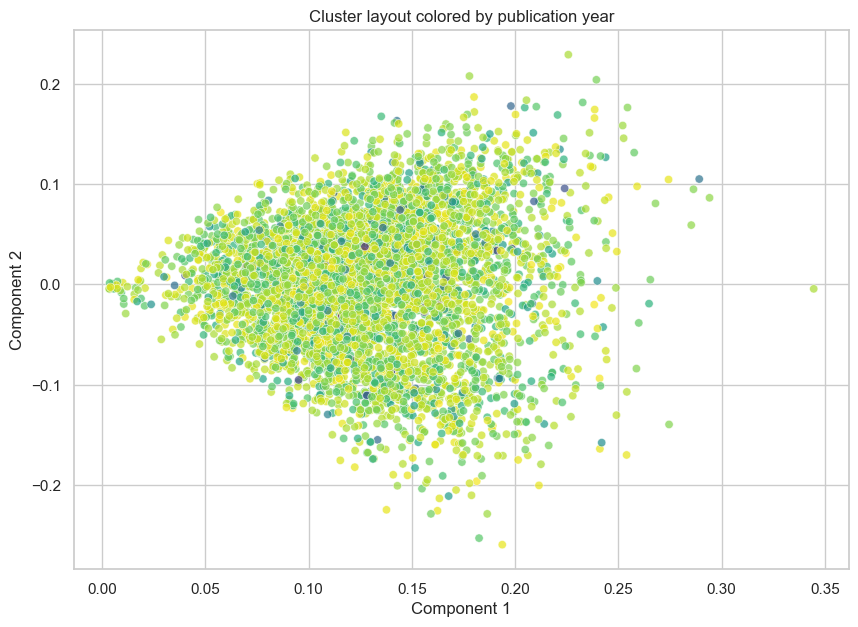

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=reduced_matrix[plot_sample.index, 0],
    y=reduced_matrix[plot_sample.index, 1],
    hue=plot_sample["year"],
    palette="viridis",
    legend=False,
    alpha=0.7
)
plt.title("Cluster layout colored by publication year")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

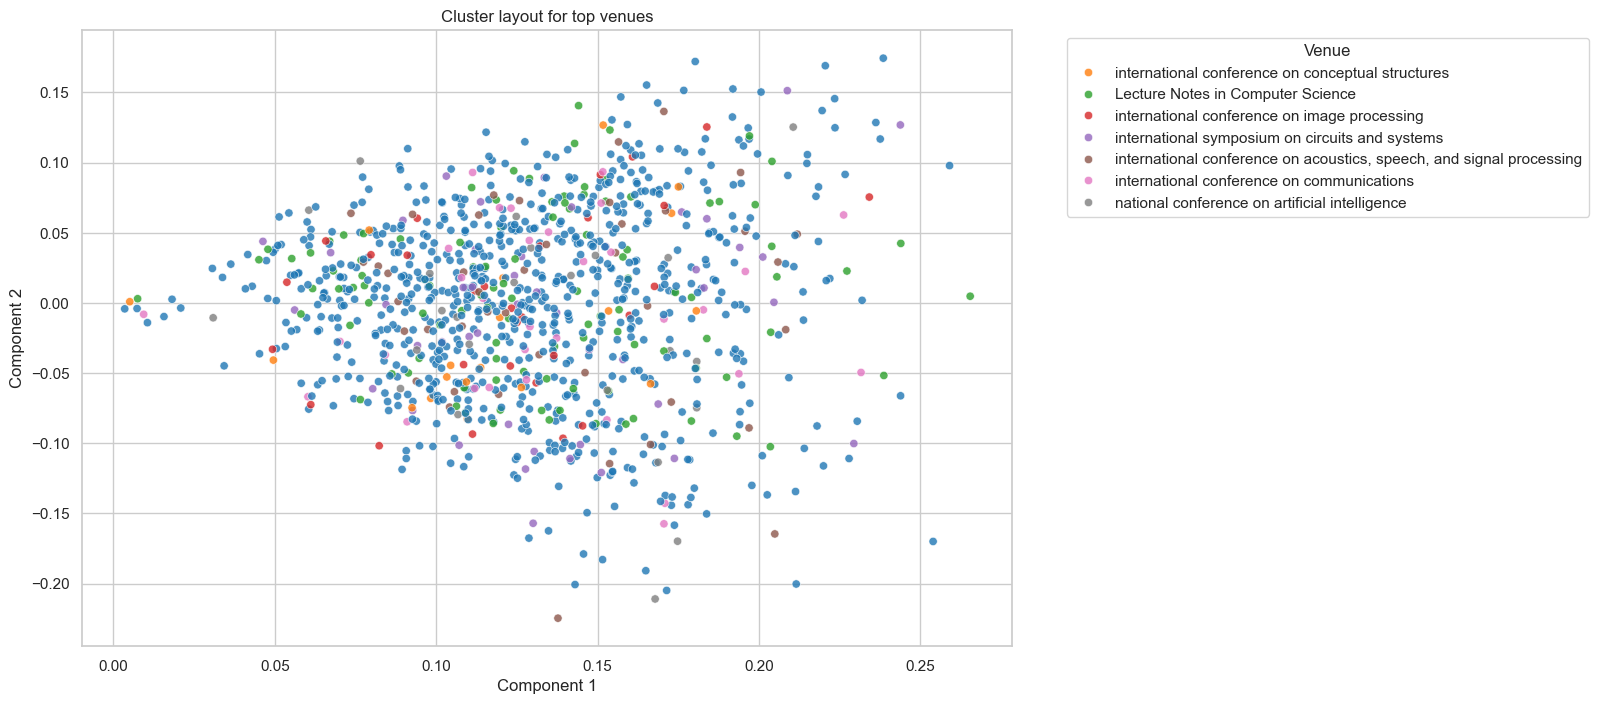

In [19]:
top_venues = analyticalData["venue"].value_counts().head(8).index.tolist()
plot_venues = plot_sample[plot_sample["venue"].isin(top_venues)].copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=reduced_matrix[plot_venues.index, 0],
    y=reduced_matrix[plot_venues.index, 1],
    hue=plot_venues["venue"],
    palette="tab10",
    alpha=0.8
)
plt.title("Cluster layout for top venues")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Venue", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()